In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
if size(LOAD_PATH,1) < 4
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end

  Activating project at `c:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV`


4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\notebooks\\..\\scripts"

In [2]:
using TetGen
using StaticArrays
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots



In [3]:
include("../scripts/TesselationCore.jl")
import .TesselationCore

BVH = TesselationCore.BVH
point3 = TesselationCore.point3

SVector{3, Float64} (alias for SArray{Tuple{3}, Float64, 1, 3})

In [4]:
Pkg.add(url="https://github.com/illustristng/illustris_julia.git")

    Updating git-repo `https://github.com/illustristng/illustris_julia.git`
   Resolving package versions...
  No Changes to `C:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV\Project.toml`
  No Changes to `C:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV\Manifest.toml`


In [5]:
import illustris_julia as il

#basePath = "../../ThesisMaster/Illustris/"; #virgo
basePath = "../../DTFE/Illustris3/output"; # laptop

fields = ["Masses","Coordinates","ParticleIDs"];

load135 = il.snapshot.loadSubset(basePath,135,"gas",fields)
gap = 10000
points = load135["Coordinates"][:,1:gap:end]

load135 = nothing
ps = [point3(points[1,i], points[2,i], points[3,i]) for i in 1:size(points,2)]

bvh,tes,tets = TesselationCore.standardEstimator(ps,12)
print("Done")

Done

# Estimator Construction Benchmarks

In [6]:
Ns = [1,5,9,12,15,16,17,18,19,20,21,22,23,24]
Ts = []
errs = []
statses = []

for n in Ns

    bench = @benchmarkable TesselationCore.standardEstimator(ps,$n)
    stats = run(bench)
    push!(Ts,mean(stats).time)
    push!(errs,std(stats).time)
    push!(statses,stats)
    
    println(n)
end

1
5
9
12
15
16
17
18
19
20
21
22
23
24


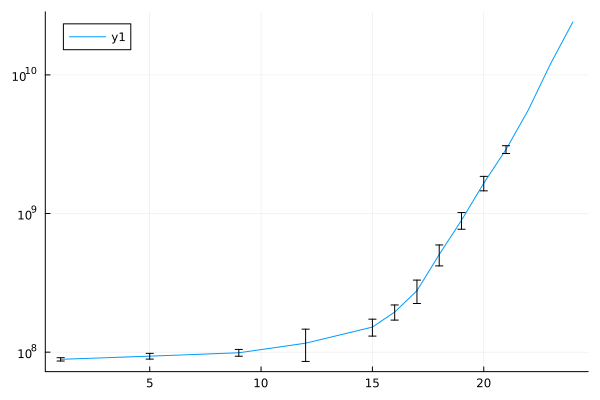

In [7]:
Plots.plot(Ns,Ts,yerr = errs,yscale=:log10)

In [8]:
using LsqFit, Statistics

model(N, p) = p[1] .* (2 .^N) .+ p[2]

p0 = [1.0, 1e8]  # initial guess for [a, b]



fit = LsqFit.curve_fit(model, Ns, Ts, p0,inplace=false)

params = coef(fit)
errors = stderror(fit)

println("a = $(params[1]) ± $(errors[1])")
println("b = $(params[2]) ± $(errors[2])")



a = 1424.2654188914578 ± 8.882103905838212
b = 6.4389904624263264e7 ± 4.598761624951729e7


In [9]:
Plots.plot(Ns,Ts,yerr = errs,yscale=:log10,label="Data")
Plots.plot!(Ns,model(Ns,params),yscale=:log10,label = "Exponential Model")
savefig("../Images/TreeGrowth.png")

"c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\Images\\TreeGrowth.png"

# Estimator Lookup Benchmarks

In [10]:
Ns = [1,5,9,12,15,16,17,18,19,20,21,22,23,24]#30,40,50]
means = []
meds = []

results = []

midPoint = mean(bvh.bbox,dims=2)[:,1]

for n in Ns

    bvh,tes,tets = TesselationCore.standardEstimator(ps,n)


    bench = @benchmarkable TesselationCore.DTFE(midPoint,bvh,tets,tes)
    stats = run(bench)
    push!(meds,median(stats).time)
    push!(means,mean(stats).time)
    
    println(n)
end

1
5
9
12
15
16
17
18
19
20
21
22
23
24


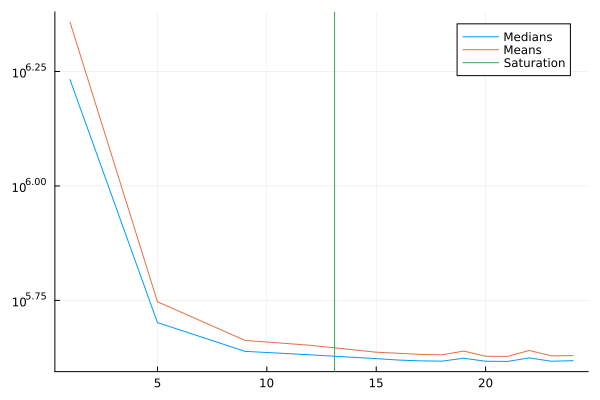

In [11]:
Plots.plot(Ns,meds,label="Medians",yscale=:log10)
Plots.plot!(Ns,means,label="Means")
Plots.vline!([log(size(ps,1))/log(2)],label = "Saturation")

In [12]:
Plots.plot(Ns,meds,label="Medians")
Plots.plot!(Ns,means,label="Means")
Plots.vline!([log(size(ps,1))/log(2)],label = "Saturation")
savefig("../Images/EstimationTime.png")

"c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\Images\\EstimationTime.png"

# Leaf Hunting

In [13]:
function countLeaves(tree)
    count = 0
    
    if typeof(tree.leftChild) == TesselationCore.Bvh.BVHLeaf
        count +=1
    else 
        count += countLeaves(tree.leftChild)
    end
    if typeof(tree.rightChild) == TesselationCore.Bvh.BVHLeaf
        count +=1
    else 
        count += countLeaves(tree.rightChild)
    end

    return count

end


countLeaves (generic function with 1 method)

In [14]:
Ns = [1,5,9,12,15,16,17,18,19,20]
leavz = []

for n in Ns

    bvh,tes,tets = TesselationCore.standardEstimator(ps,n)

    push!(leavz,countLeaves(bvh.tree))
    
    println(n)
end

1
5
9
12
15
16
17
18
19
20


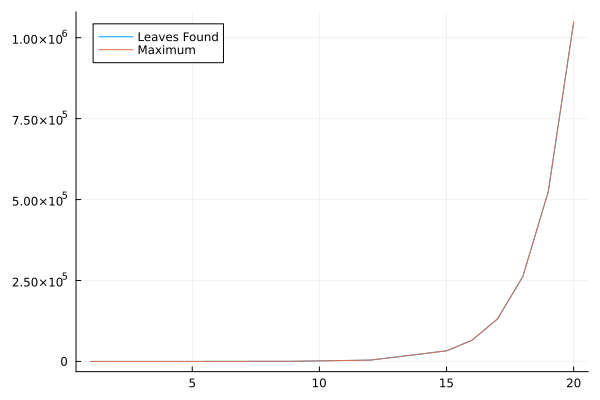

In [15]:
Plots.plot(Ns,leavz,label="Leaves Found")
Plots.plot!(Ns, 2 .^Ns,label="Maximum")

In [16]:
Plots.plot(Ns,leavz - 2 .^Ns)

savefig("../Images/Leaves.png")

"c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\Images\\Leaves.png"